## Análise de Dependência Parcial

### PARAMETROS

In [208]:
# PARÂMETROS
random_seed = 42
k_of_k_folds = 5
dependent_variable = 'petal_length'
independent_variables = ["petal_width", "sepal_length", "sepal_width", 'sepal_area']

# GOURMET
palette = ['limegreen', 'indianred', 'gold']

In [209]:
from itertools import product

import numpy
import pandas
import seaborn
from matplotlib import pyplot
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.datasets import load_iris
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [210]:
class DummyRegressor(RegressorMixin, BaseEstimator):
    def fit(self, X, y):
        self.y_mean_ = numpy.mean(y)
        return self

    def predict(self, X):
        return numpy.full(X.shape[0], self.y_mean_)

### IMPORT IRIS

In [211]:
iris_dict = load_iris()
iris = pandas.DataFrame(iris_dict['data'])
iris.columns = iris_dict['feature_names']
iris.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
iris['sepal_area'] = iris['sepal_length'] * iris['sepal_width']
iris['target'] = iris_dict['target']
iris['species'] = iris['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

iris

,sepal_length,sepal_width,petal_length,petal_width,sepal_area,target,species
0,5.1,3.5,1.4,0.2,17.85,0,setosa
1,4.9,3.0,1.4,0.2,14.70,0,setosa
2,4.7,3.2,1.3,0.2,15.04,0,setosa
3,4.6,3.1,1.5,0.2,14.26,0,setosa
4,5.0,3.6,1.4,0.2,18.00,0,setosa
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,20.10,2,virginica
146,6.3,2.5,5.0,1.9,15.75,2,virginica
147,6.5,3.0,5.2,2.0,19.50,2,virginica
148,6.2,3.4,5.4,2.3,21.08,2,virginica


### PAIRPLOT

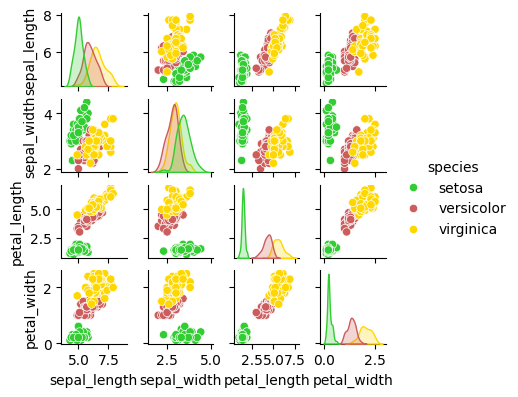

In [212]:
_ = seaborn.pairplot(iris[["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]], hue='species', palette=palette, height=1.0)

### LOOP DE TREINAMENTO

> Pipelines

> GridSearchCV

> PDP / ICE (Análise de Dependência Parcial)

In [213]:
# RANDOM SEED
numpy.random.seed(random_seed)

X = iris[independent_variables]
y = iris[dependent_variable]

In [214]:
linear_regression = GridSearchCV(Pipeline(steps=[("scaler", StandardScaler()), ("algorithm", LinearRegression())]), param_grid={}, cv=k_of_k_folds, verbose=2, n_jobs=-1).fit(X, y).best_estimator_
linear_regression

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Pipeline(steps=[('scaler', StandardScaler()),
                ('algorithm', LinearRegression())])

### Comparar o PDP da Regressão Vs Lasso vs Ridge

In [228]:
ncols = 4
nrows = 1
fig_size = (16, 4)
features = [0, 1, 2, 3]

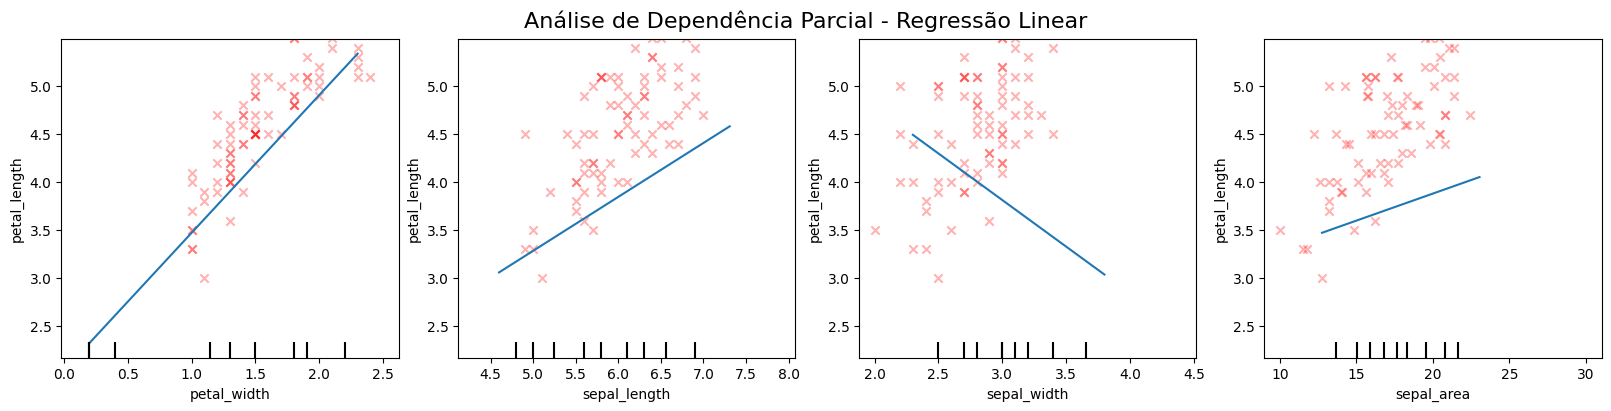

In [229]:
fig, axs = pyplot.subplots(ncols=ncols, nrows=nrows, figsize=fig_size, constrained_layout=True)
display = PartialDependenceDisplay.from_estimator(linear_regression, X, features=features, random_state=random_seed, n_jobs=-1, subsample=50, grid_resolution=20,ax=axs)

for ix, ax in enumerate(axs):
    ax.set_ylabel(dependent_variable)
    ax.scatter(X.iloc[:, ix], y, marker='x', color='red', alpha=0.3)

_ = fig.suptitle("Análise de Dependência Parcial - Regressão Linear", fontsize=16)

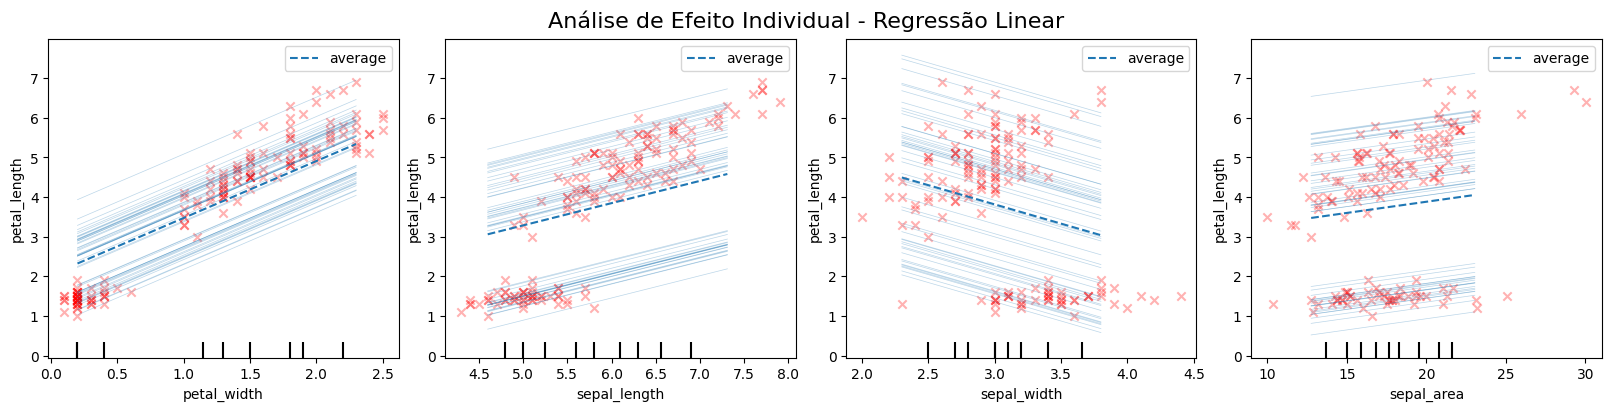

In [230]:
fig, axs = pyplot.subplots(ncols=ncols, nrows=nrows, figsize=fig_size, constrained_layout=True)
display = PartialDependenceDisplay.from_estimator(linear_regression, X, features=features, random_state=random_seed, n_jobs=-1, subsample=50, grid_resolution=20,ax=axs, kind="both")

for ix, ax in enumerate(axs):
    ax.set_ylabel(dependent_variable)
    ax.scatter(X.iloc[:, ix], y, marker='x', color='red', alpha=0.3)

_ = fig.suptitle("Análise de Efeito Individual - Regressão Linear", fontsize=16)

In [217]:
param_grid = [{
    "algorithm__kernel" : ['rbf','sigmoid'],
    "algorithm__C" : [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    "algorithm__gamma" : ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
}]

svr = GridSearchCV(Pipeline(steps=[("scaler", StandardScaler()), ("algorithm", SVR())]), param_grid=param_grid, cv=k_of_k_folds, verbose=2, n_jobs=-1).fit(X, y).best_estimator_
svr

Fitting 5 folds for each of 112 candidates, totalling 560 fits


Pipeline(steps=[('scaler', StandardScaler()),
                ('algorithm', SVR(C=100.0, gamma=0.1))])

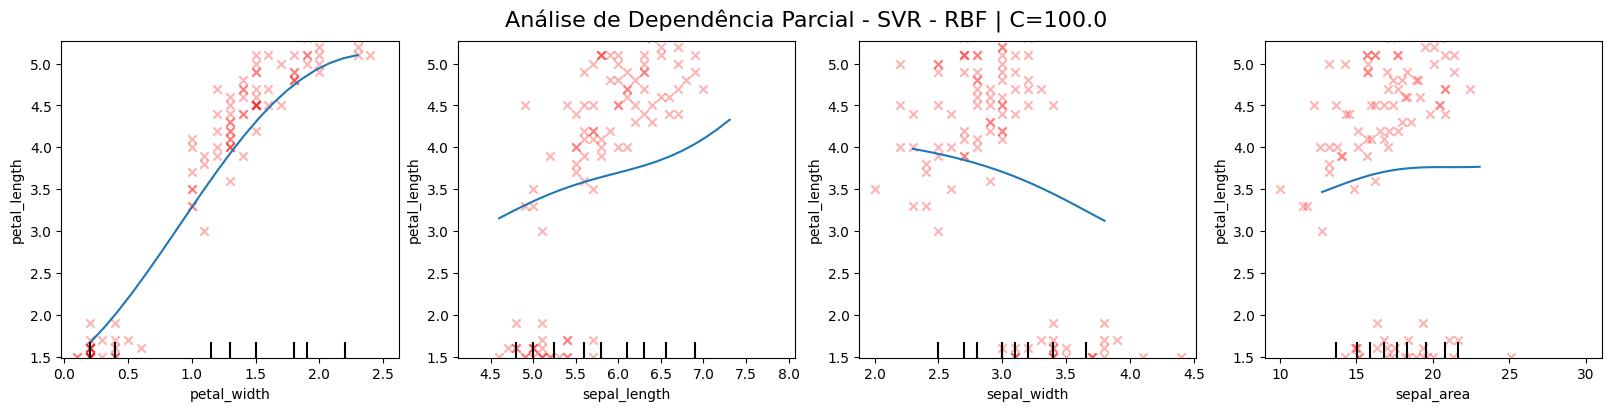

In [231]:
fig, axs = pyplot.subplots(ncols=ncols, nrows=nrows, figsize=fig_size, constrained_layout=True)
display = PartialDependenceDisplay.from_estimator(svr, X, features=features, random_state=random_seed, n_jobs=-1, subsample=50, grid_resolution=20,ax=axs)

for ix, ax in enumerate(axs):
    ax.set_ylabel(dependent_variable)
    ax.scatter(X.iloc[:, ix], y, marker='x', color='red', alpha=0.3)

_ = fig.suptitle(f"Análise de Dependência Parcial - SVR - {svr.get_params()['algorithm__kernel'].upper()} | C={svr.get_params()['algorithm__C']}", fontsize=16)

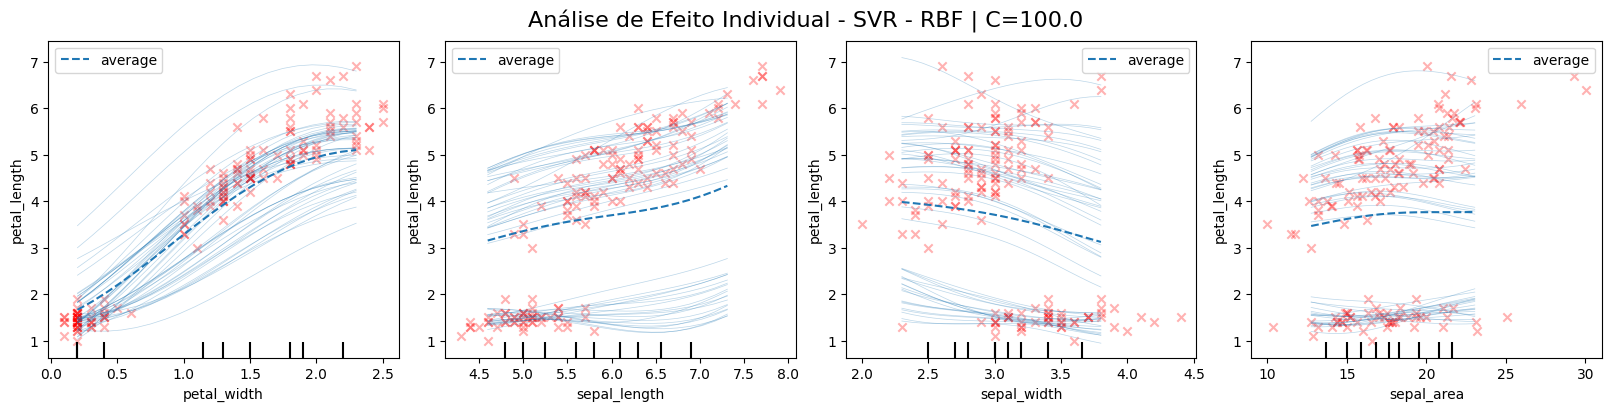

In [232]:
fig, axs = pyplot.subplots(ncols=ncols, nrows=1, figsize=fig_size, constrained_layout=True)
display = PartialDependenceDisplay.from_estimator(svr, X, features=features, random_state=random_seed, n_jobs=-1, subsample=50, grid_resolution=20,ax=axs, kind="both")

for ix, ax in enumerate(axs):
    ax.set_ylabel(dependent_variable)
    ax.scatter(X.iloc[:, ix], y, marker='x', color='red', alpha=0.3)

_ = fig.suptitle(f"Análise de Efeito Individual - SVR - {svr.get_params()['algorithm__kernel'].upper()} | C={svr.get_params()['algorithm__C']}", fontsize=16)

In [220]:
param_grid = [{
    "algorithm__n_neighbors" : [3,5,7,9,11,13,15],
    "algorithm__weights" : ['uniform','distance'],
}]

nearest_neighbors = GridSearchCV(Pipeline(steps=[("scaler", StandardScaler()), ("algorithm", KNeighborsRegressor())]), param_grid=param_grid, cv=k_of_k_folds, verbose=2, n_jobs=-1).fit(X, y).best_estimator_
nearest_neighbors

Fitting 5 folds for each of 14 candidates, totalling 70 fits


Pipeline(steps=[('scaler', StandardScaler()),
                ('algorithm',
                 KNeighborsRegressor(n_neighbors=3, weights='distance'))])

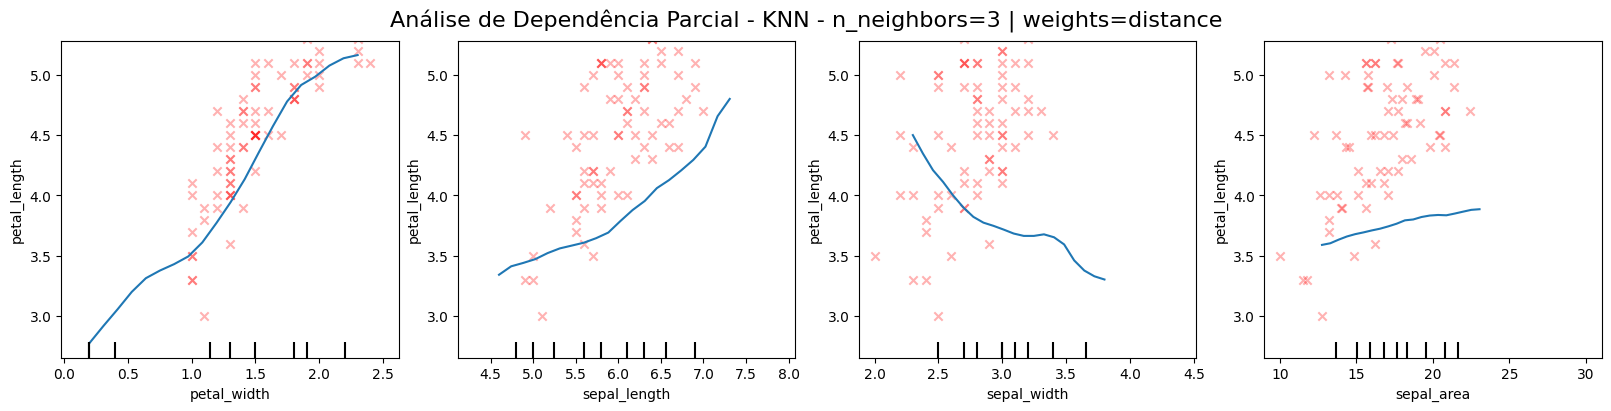

In [233]:
fig, axs = pyplot.subplots(ncols=ncols, nrows=1, figsize=fig_size, constrained_layout=True)
display = PartialDependenceDisplay.from_estimator(nearest_neighbors, X, features=features, random_state=random_seed, n_jobs=-1, subsample=50, grid_resolution=20,ax=axs)

for ix, ax in enumerate(axs):
    ax.set_ylabel(dependent_variable)
    ax.scatter(X.iloc[:, ix], y, marker='x', color='red', alpha=0.3)

_ = fig.suptitle(f"Análise de Dependência Parcial - KNN - n_neighbors={nearest_neighbors.get_params()['algorithm__n_neighbors']} | weights={nearest_neighbors.get_params()['algorithm__weights']}", fontsize=16)

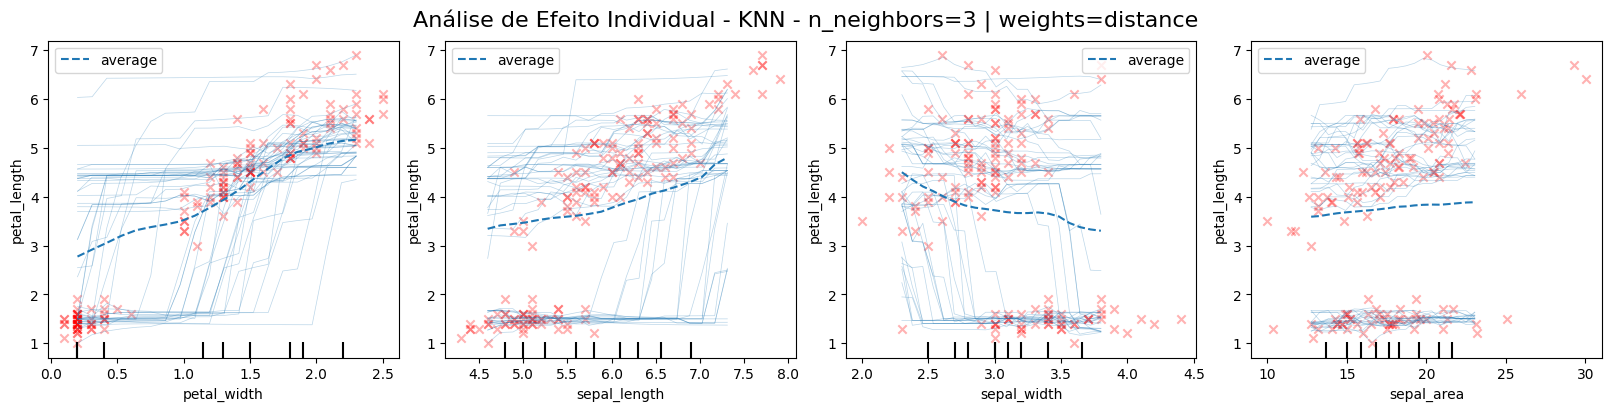

In [234]:
fig, axs = pyplot.subplots(ncols=ncols, nrows=1, figsize=fig_size, constrained_layout=True)
display = PartialDependenceDisplay.from_estimator(nearest_neighbors, X, features=features, random_state=random_seed, n_jobs=-1, subsample=50, grid_resolution=20,ax=axs, kind="both")

for ix, ax in enumerate(axs):
    ax.set_ylabel(dependent_variable)
    ax.scatter(X.iloc[:, ix], y, marker='x', color='red', alpha=0.3)

_ = fig.suptitle(f"Análise de Efeito Individual - KNN - n_neighbors={nearest_neighbors.get_params()['algorithm__n_neighbors']} | weights={nearest_neighbors.get_params()['algorithm__weights']}", fontsize=16)

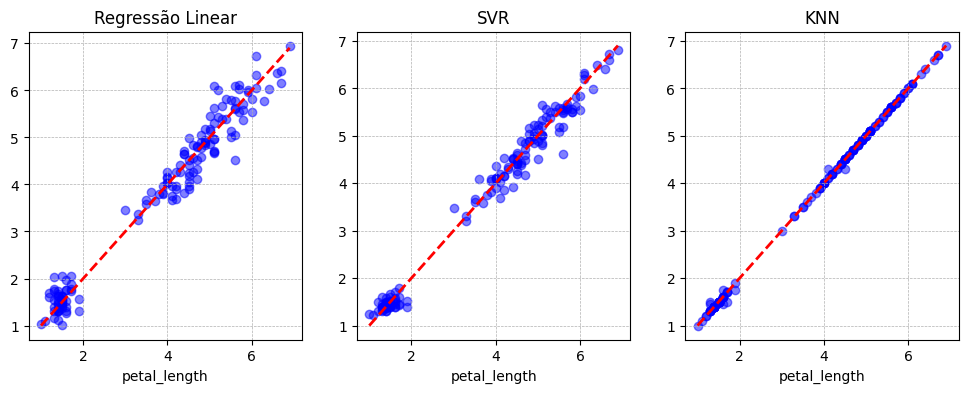

In [223]:
fig = pyplot.figure(figsize=(12,4))
ax = fig.add_subplot(131)
# PLOT Y vs Y EST
_ = ax.scatter(y, linear_regression.predict(X), marker='o', color='blue', alpha=0.5)
_ = ax.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2)
_ = ax.grid(which='both', linestyle='--', linewidth=0.5)
_ = ax.set_xlabel(dependent_variable)
_ = ax.set_title("Regressão Linear")

ax = fig.add_subplot(132)
# PLOT Y vs Y EST
_ = ax.scatter(y, svr.predict(X), marker='o', color='blue', alpha=0.5)
_ = ax.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2)
_ = ax.grid(which='both', linestyle='--', linewidth=0.5)
_ = ax.set_xlabel(dependent_variable)
_ = ax.set_title("SVR")

ax = fig.add_subplot(133)
# PLOT Y vs Y EST
_ = ax.scatter(y, nearest_neighbors.predict(X), marker='o', color='blue', alpha=0.5)
_ = ax.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2)
_ = ax.grid(which='both', linestyle='--', linewidth=0.5)
_ = ax.set_title("KNN")
_ = ax.set_xlabel(dependent_variable)